# Hejka


In [2]:
print("HEJ")

HEJ


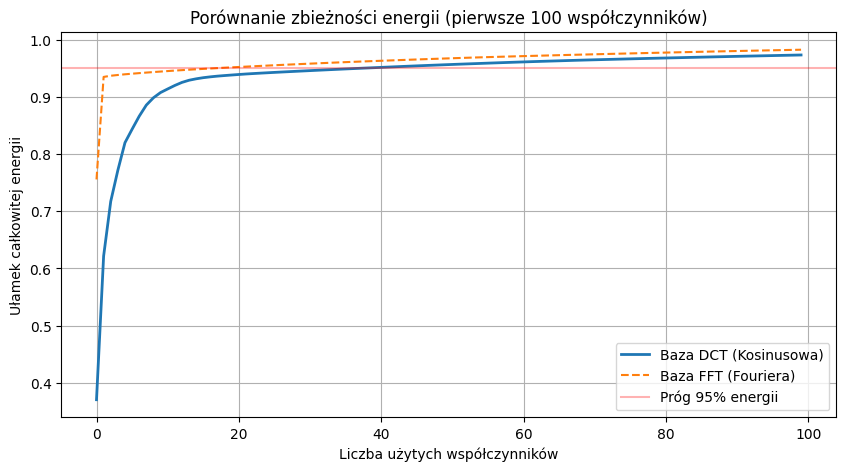

In [5]:
import numpy as np
import scipy.fftpack as fftpack
import matplotlib.pyplot as plt

# 1. Tworzymy sygnał testowy (suma sinusów - model prostego dźwięku)
N = 512
t = np.linspace(0, 1, N)
signal = np.sin(2 * np.pi * 5 * t) + 0.5 * np.sin(2 * np.pi * 20 * t) + 0.2 * np.random.randn(N)

# 2. Obliczamy współczynniki w dwóch bazach
# FFT (Fourier) - bierzemy moduł, bo FFT daje liczby zespolone
coef_fft = np.abs(np.fft.rfft(signal)) 
# DCT (Kosinusowa) - standard w audio
coef_dct = np.abs(fftpack.dct(signal, norm='ortho'))

# 3. Funkcja do obliczania skumulowanej energii (zbieżności)
def get_energy_convergence(coeffs):
    # Sortujemy współczynniki od największego (najważniejszego) do najmniejszego
    sorted_coeffs = np.sort(np.abs(coeffs))[::-1]
    # Liczymy sumę skumulowaną kwadratów (energia to kwadrat amplitudy)
    energy_cumulative = np.cumsum(sorted_coeffs**2)
    # Normalizujemy do 1.0 (czyli do 100%)
    return energy_cumulative / energy_cumulative[-1]

# 4. Obliczamy krzywe zbieżności
energy_fft = get_energy_convergence(coef_fft)
energy_dct = get_energy_convergence(coef_dct)

# 5. Wykres porównawczy
plt.figure(figsize=(10, 5))
plt.plot(energy_dct[:100], label='Baza DCT (Kosinusowa)', linewidth=2)
plt.plot(energy_fft[:100], label='Baza FFT (Fouriera)', linestyle='--')
plt.axhline(y=0.95, color='r', alpha=0.3, label='Próg 95% energii')
plt.title("Porównanie zbieżności energii (pierwsze 100 współczynników)")
plt.xlabel("Liczba użytych współczynników")
plt.ylabel("Ułamek całkowitej energii")
plt.legend()
plt.grid(True)
plt.show()